In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
df=pd.read_csv("Salary_Data.csv")

In [25]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


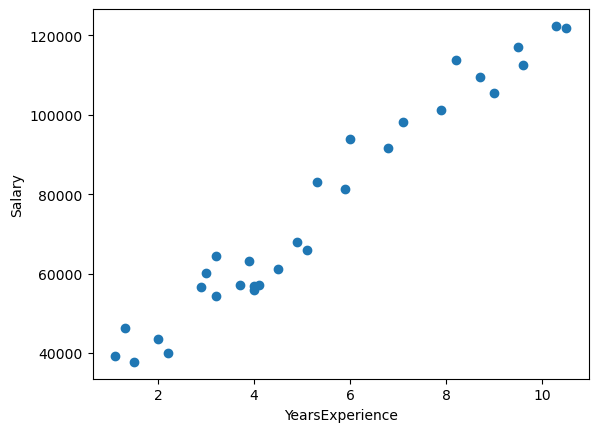

In [26]:
plt.scatter(df['YearsExperience'],df['Salary'])
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

In [27]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


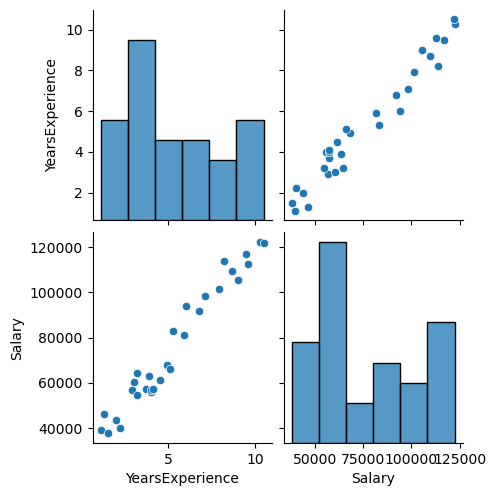

In [28]:
import seaborn as sns
sns.pairplot(df)
plt.show()

In [39]:
X=df[['YearsExperience']]
Y=df['Salary']
X.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [40]:
Y.head()

0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
Name: Salary, dtype: float64

In [41]:
np.array(X).shape

(30, 1)

In [43]:
X_series=df['YearsExperience']
np.array(X_series).shape

(30,)

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)
X_train.shape

(22, 1)

In [45]:
## standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [47]:
X_train=scaler.fit_transform(X_train)
X_train

array([[-0.29741739],
       [-1.38171623],
       [-0.97043047],
       [ 0.11386837],
       [-0.70870316],
       [-0.26002778],
       [-0.29741739],
       [ 1.1607776 ],
       [-1.306937  ],
       [-1.23215777],
       [ 1.57206337],
       [-1.0452097 ],
       [ 0.86166068],
       [ 1.75901144],
       [ 0.41298529],
       [ 2.13290759],
       [ 0.74949183],
       [-0.59653431],
       [-0.33480701],
       [-0.11046932],
       [ 0.45037491],
       [-0.67131355]])

In [52]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,Y_train)

LinearRegression()

In [53]:
print(regression.coef_)
print(regression.intercept_)

[25063.1519945]
70416.40909090909


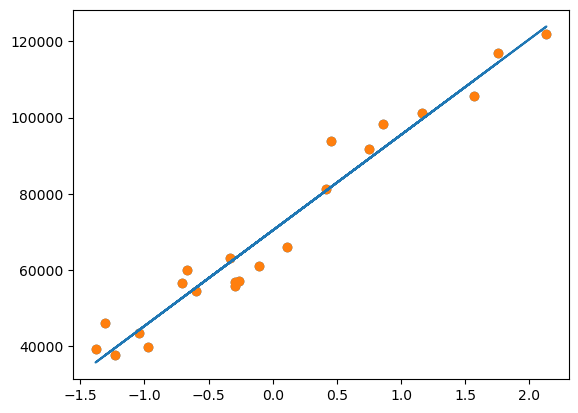

In [56]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train))
plt.show()

In [57]:
Y_pred=regression.predict(X_test)

C:\Users\nehas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [59]:
## performace metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(Y_test,Y_pred)
mae=mean_absolute_error(Y_test,Y_pred)
rmse=np.sqrt(mse)
print('mse:',mse)
print('mae:',mae)
print('rmse:',rmse)

mse: 23624136901.400337
mae: 147913.27065386693
rmse: 153701.45380379568


In [60]:
from sklearn.metrics import r2_score
score=r2_score(Y_test,Y_pred)
print(score)
## Adjusted R square
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

-38.743739955076066


-45.36769661425541

In [61]:
## OLS linear
import statsmodels.api as sm
model=sm.OLS(Y_train,X_train).fit()
prediction=model.predict(X_test)
print(prediction)

27    240606.259147
15    122809.444773
23    205517.846355
17    132834.705571
8      80202.086382
9      92733.662380
28    258150.465543
24    218049.422352
dtype: float64


In [62]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.112
Model:                            OLS   Adj. R-squared (uncentered):              0.070
Method:                 Least Squares   F-statistic:                              2.645
Date:                Sat, 07 Feb 2026   Prob (F-statistic):                       0.119
Time:                        10:27:19   Log-Likelihood:                         -276.85
No. Observations:                  22   AIC:                                      555.7
Df Residuals:                      21   BIC:                                      556.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [67]:
regression.predict(scaler.transform([[10]]))

array([321047.92903593])